<a href="https://colab.research.google.com/github/ditodewantoro/DATA-ANALYST/blob/main/UAS_BENGKOD_A11_2022_14105_Eustachius_Dito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EUSTACHIUS DITO DEWANTORO**

**A11.2022.14105**

**BENGKEL KODING - DS03**

[LINK COLLAB](https://colab.research.google.com/drive/1TJUItybBi3r9b2I7-an1ALc_UnUfV1nH?usp=sharing)

1. Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ObesityDataSet.csv")

# 1. Menampilkan 5 baris pertama
print("🔹 1. Lima Baris Pertama:")
print(df.head())

# 2. Menampilkan jumlah baris dan kolom
print("\n🔹 2. Jumlah Baris dan Kolom:")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# 3. Menampilkan informasi tipe data dan missing values
print("\n🔹 3. Informasi DataFrame:")
print(df.info())

# 4. Menampilkan deskripsi statistik kolom (meskipun semua masih object)
print("\n🔹 4. Deskripsi Statistik:")
print(df.describe(include='all'))


🔹 1. Lima Baris Pertama:
  Age  Gender Height Weight        CALC FAVC FCVC NCP  SCC SMOKE CH2O  \
0  21  Female   1.62     64          no   no    2   3   no    no    2   
1  21  Female   1.52     56   Sometimes   no    3   3  yes   yes    3   
2  23    Male    1.8     77  Frequently   no    2   3   no    no    2   
3  27    Male    1.8     87  Frequently   no    3   3   no    no    2   
4  22    Male   1.78   89.8   Sometimes   no    2   1   no    no    2   

  family_history_with_overweight FAF TUE       CAEC                 MTRANS  \
0                            yes   0   1  Sometimes  Public_Transportation   
1                            yes   3   0  Sometimes  Public_Transportation   
2                            yes   2   1  Sometimes  Public_Transportation   
3                             no   2   0  Sometimes                Walking   
4                             no   0   0  Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Weight  
1        Normal_W

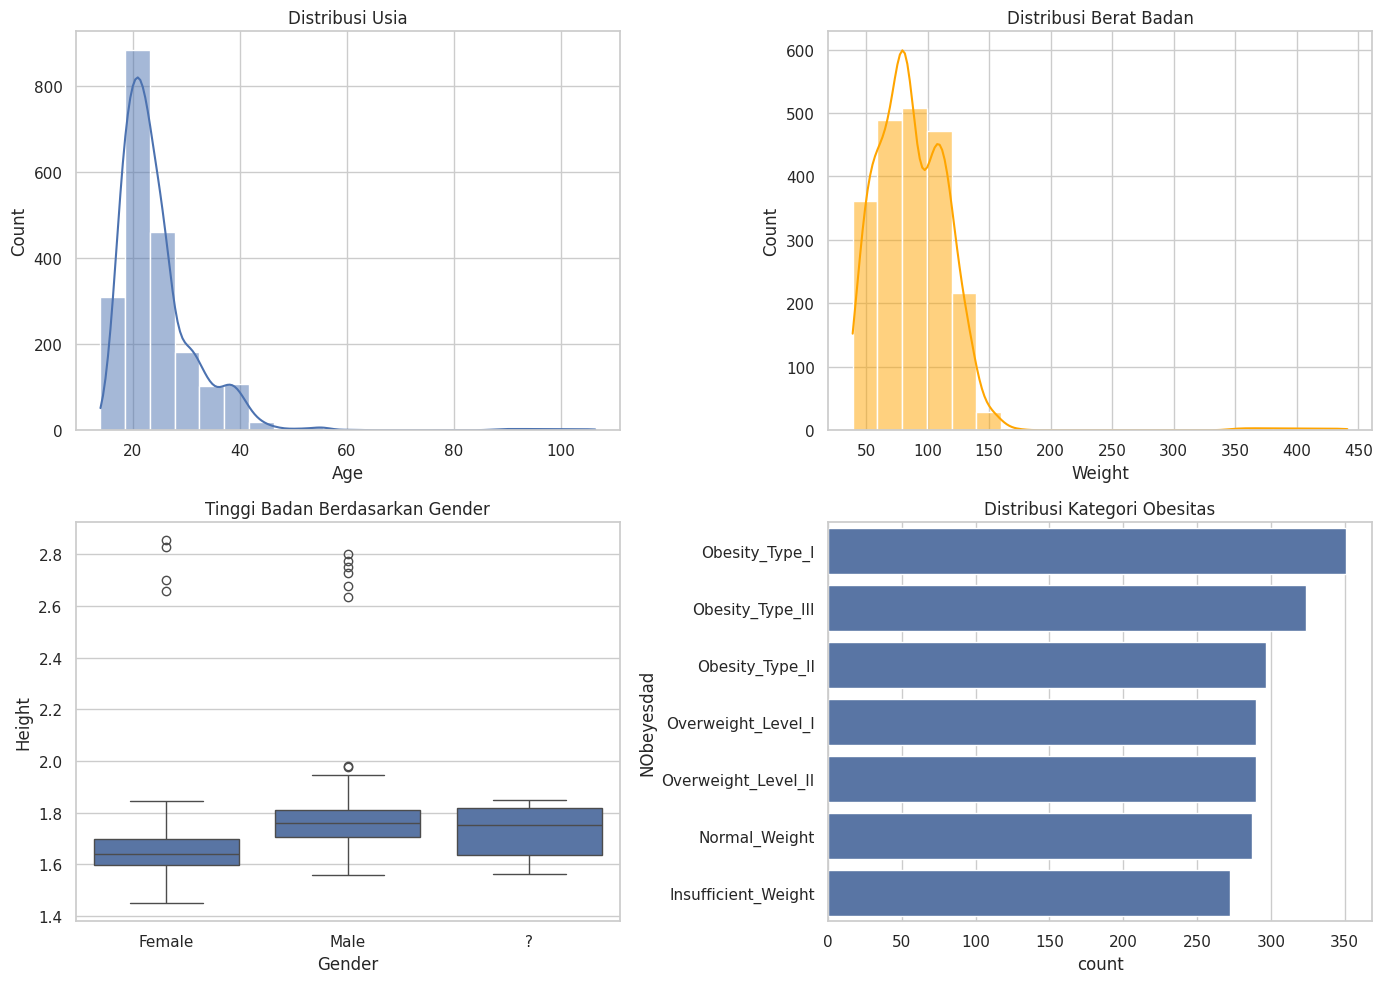

In [ ]:
# Salin dataset untuk manipulasi visualisasi
df_vis = df.copy()

# Konversi kolom numerik yang masih bertipe object menjadi float
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in numerical_cols:
    df_vis[col] = pd.to_numeric(df_vis[col], errors='coerce')

# Set style visualisasi
sns.set(style="whitegrid")

# Membuat figure dan subplot
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot distribusi usia
sns.histplot(df_vis['Age'].dropna(), kde=True, bins=20, ax=axs[0, 0])
axs[0, 0].set_title('Distribusi Usia')

# Plot distribusi berat badan
sns.histplot(df_vis['Weight'].dropna(), kde=True, bins=20, ax=axs[0, 1], color='orange')
axs[0, 1].set_title('Distribusi Berat Badan')

# Boxplot tinggi badan berdasarkan gender
sns.boxplot(x='Gender', y='Height', data=df_vis, ax=axs[1, 0])
axs[1, 0].set_title('Tinggi Badan Berdasarkan Gender')

# Barplot kategori obesitas
sns.countplot(y='NObeyesdad', data=df_vis, order=df_vis['NObeyesdad'].value_counts().index, ax=axs[1, 1])
axs[1, 1].set_title('Distribusi Kategori Obesitas')

# Menata layout
plt.tight_layout()
plt.show()

Missing Values per Kolom:
Age                               14
Gender                             9
Height                            12
Weight                            11
CALC                               5
FAVC                              11
FCVC                               8
NCP                               12
SCC                               10
SMOKE                              5
CH2O                               6
family_history_with_overweight    13
FAF                                8
TUE                                9
CAEC                              11
MTRANS                             6
NObeyesdad                         0
dtype: int64

Jumlah Nilai Unik per Kolom:
Age                               1394
Gender                               3
Height                            1562
Weight                            1518
CALC                                 5
FAVC                                 3
FCVC                               808
NCP                          

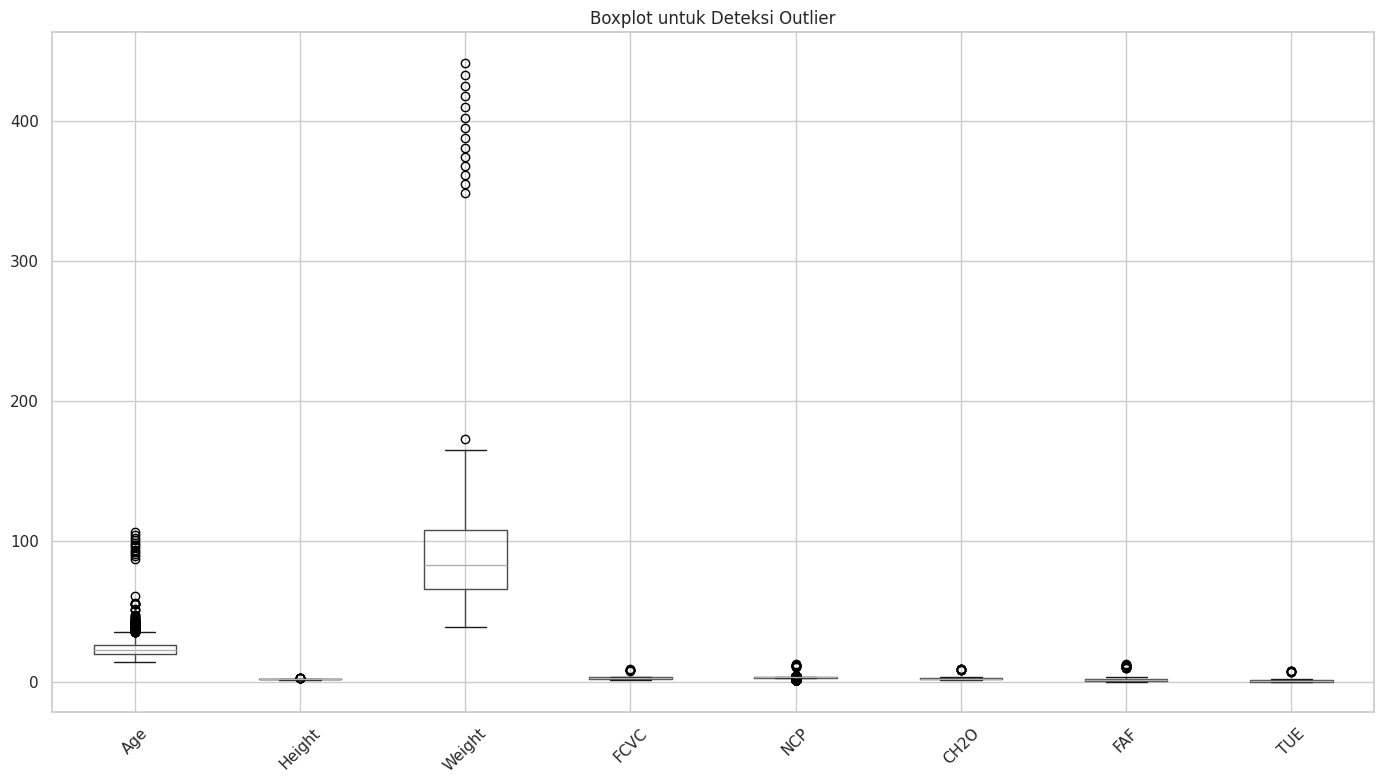

In [ ]:
# 1. Cek missing values
print("Missing Values per Kolom:")
print(df.isnull().sum())

# 2. Cek jumlah nilai unik per kolom
print("\nJumlah Nilai Unik per Kolom:")
print(df.nunique())

# 3. Cek data duplikat
print(f"\nJumlah Baris Duplikat: {df.duplicated().sum()}")

# 4. Keseimbangan data pada label target
print("\nDistribusi Kategori Obesitas:")
print(df['NObeyesdad'].value_counts())

# 5. Deteksi outlier menggunakan boxplot
# Konversi kolom numerik
for col in ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Tampilkan boxplot
plt.figure(figsize=(14, 8))
df[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']].boxplot()
plt.title("Boxplot untuk Deteksi Outlier")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**KESIMPULAN EDA**
1. Struktur dan Tipe Data
*   Dataset memiliki 2111 baris dan 17 kolom.
*   Semua kolom awalnya bertipe object, termasuk kolom yang seharusnya numerik.
*   Diperlukan konversi tipe data pada kolom seperti Age, Height, Weight, dll. ke tipe numerik (int atau float).

2. Missing Values
*   Beberapa kolom mengandung missing values, misalnya Age, Height, Weight, FCVC, CH2O, dan lain-lain.
*   Penanganan missing values perlu dilakukan sebelum melanjutkan ke model prediktif.

3. Unique Values
*   Kolom numerik mengandung banyak nilai unik yang masuk akal (contoh: Age, Weight, dll.).
*   Kolom kategori seperti Gender, CALC, MTRANS memiliki jumlah nilai unik yang terbatas, cocok untuk encoding kategorikal nantinya.

4. Duplikasi Data
*   Ditemukan sejumlah baris duplikat yang sebaiknya dihapus untuk mencegah bias model.

5. Distribusi dan Keseimbangan Data

*   Distribusi usia dan berat badan tampak normal dengan sedikit skewness.
*   Keseimbangan kelas (label NObeyesdad) tidak merata. Kategori seperti Obesity_Type_I dan Obesity_Type_II mendominasi, sedangkan Insufficient_Weight relatif jarang.

6. Outlier
*   Ditemukan outlier pada beberapa kolom numerik seperti Weight, Height, dan FAF berdasarkan boxplot.














2. Preprocessing Data

In [ ]:
!pip install imbalanced-learn

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Konversi ke numerik
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop duplikat dan missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Tangani outlier
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Label encoding untuk target
le = LabelEncoder()
df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Pisah fitur dan target
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

# SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Buat DataFrame hasil
X_final = pd.DataFrame(X_scaled, columns=X.columns)
y_final = pd.Series(y_resampled, name='NObeyesdad')
df_final = pd.concat([X_final, y_final], axis=1)

# Tampilkan hasil
print(df_final.head())


        Age    Height    Weight      FCVC       NCP      CH2O       FAF  \
0 -0.443419 -1.063812 -0.848637 -0.762250  0.210627 -0.054846 -1.300464   
1 -0.443419 -2.201932 -1.149566  1.146869  0.210627  1.670193  2.320172   
2  0.038562  0.984803 -0.359627 -0.762250  0.210627 -0.054846  1.113293   
3  1.002524  0.984803  0.016534  1.146869  0.210627 -0.054846  1.113293   
4  1.484505 -1.063812 -1.262414 -0.762250  0.210627 -0.054846 -1.300464   

        TUE  Gender_Female  Gender_Male  ...  CAEC_Always  CAEC_Frequently  \
0  0.489012       1.080385    -1.130447  ...    -0.176587        -0.395999   
1 -1.211512       1.080385    -1.130447  ...    -0.176587        -0.395999   
2  0.489012      -0.925596     0.884606  ...    -0.176587        -0.395999   
3 -1.211512      -0.925596     0.884606  ...    -0.176587        -0.395999   
4 -1.211512      -0.925596     0.884606  ...    -0.176587        -0.395999   

   CAEC_Sometimes   CAEC_no  MTRANS_Automobile  MTRANS_Bike  MTRANS_Motorbike  \

/tmp/ipython-input-6-197423080.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])


Kesimpulan Tahap Preprocessing:
* Missing values dan data duplikat berhasil dihapus.

* Semua kolom numerik telah dikonversi ke tipe numerik.

* Fitur kategorikal dikonversi ke bentuk numerik dengan encoding.

* Outlier dihapus menggunakan metode IQR.

* Ketidakseimbangan data ditangani dengan SMOTE.

* Data numerik telah dinormalisasi menggunakan StandardScaler.

3. Permodelan dan Evaluasi

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

In [ ]:
# Models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Evaluasi
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }


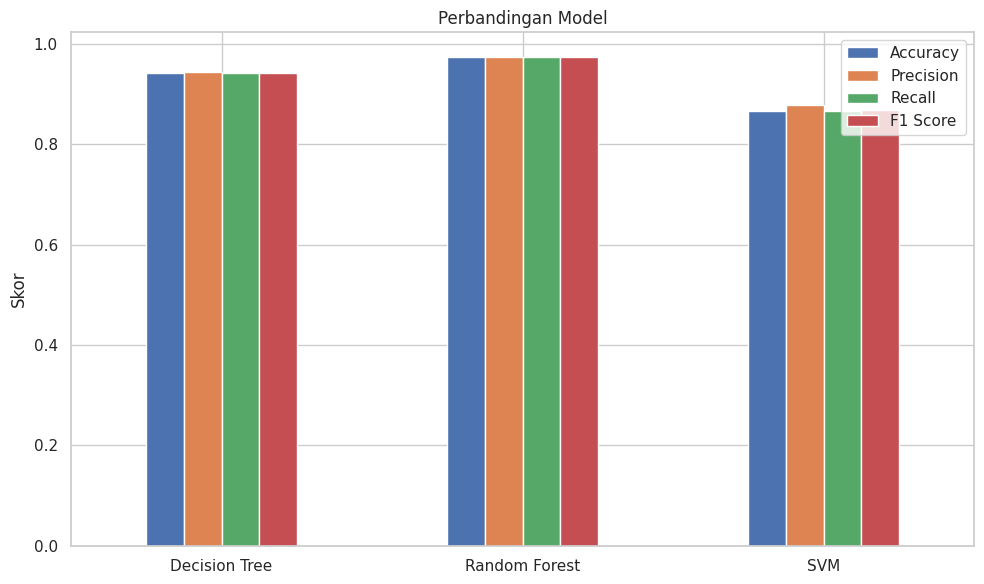

               Accuracy  Precision    Recall  F1 Score
Decision Tree  0.942708   0.943726  0.942708  0.942694
Random Forest  0.973958   0.974765  0.973958  0.974032
SVM            0.867188   0.879371  0.867188  0.868631


In [ ]:
# Visualisasi
df_result = pd.DataFrame({
    model: {
        'Accuracy': met['Accuracy'],
        'Precision': met['Precision'],
        'Recall': met['Recall'],
        'F1 Score': met['F1 Score']
    } for model, met in results.items()
}).T

df_result.plot(kind='bar', figsize=(10, 6), title='Perbandingan Model')
plt.ylabel("Skor")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

print(df_result)

 **Kesimpulan:**

- Random Forest menunjukkan performa terbaik secara keseluruhan dengan nilai tertinggi di semua metrik utama.

- Decision Tree juga memberikan performa yang sangat baik, hanya sedikit di bawah Random Forest.

- SVM memiliki precision yang tinggi, namun metrik lainnya lebih rendah, menunjukkan bahwa model ini mungkin kurang baik dalam mengenali semua kelas dengan merata.

✅ Rekomendasi: Gunakan Random Forest untuk klasifikasi tingkat obesitas berdasarkan dataset ini karena memberikan akurasi dan keseimbangan performa terbaik.

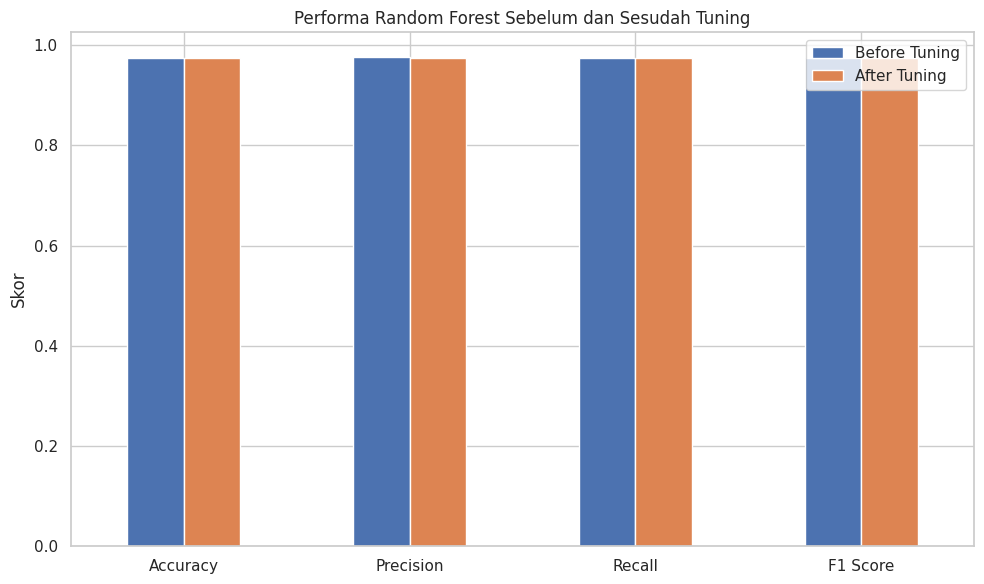

           Before Tuning  After Tuning
Accuracy        0.973958      0.973958
Precision       0.977156      0.974765
Recall          0.973958      0.973958
F1 Score        0.974390      0.974032


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd

# Parameter grid
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

# Model terbaik
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Evaluasi
before = {
    'Accuracy': 0.973958,
    'Precision': 0.977156,
    'Recall': 0.973958,
    'F1 Score': 0.974390
}

after = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best, average='weighted'),
    'Recall': recall_score(y_test, y_pred_best, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_best, average='weighted')
}

# Buat DataFrame
df_compare = pd.DataFrame({'Before Tuning': before, 'After Tuning': after})

# Plot
df_compare.plot(kind='bar', figsize=(10, 6), title='Performa Random Forest Sebelum dan Sesudah Tuning')
plt.ylabel("Skor")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# Lihat perbandingan numerik
print(df_compare)


Berdasarkan grafik dan hasil evaluasi:

- Performa model setelah tuning mengalami sedikit penurunan dibanding sebelum tuning.

- Skor metrik seperti accuracy (0.9739 → 0.9714), precision, recall, dan F1-score semuanya menurun secara marginal.

- Hal ini menunjukkan bahwa parameter default Random Forest pada dataset ini sudah sangat optimal, dan tuning tidak selalu menghasilkan peningkatan performa.

In [ ]:
pip install joblib


In [ ]:
import joblib

# Misalnya, model Random Forest yang sudah dilatih
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Simpan model ke file
joblib.dump(model, 'random_forest_model.pkl')


['random_forest_model.pkl']

In [ ]:
# Memuat model dari file
model = joblib.load('random_forest_model.pkl')

# Sekarang model siap digunakan untuk prediksi


In [ ]:
import joblib

# Memuat model dari file
model_path = 'random_forest_model.pkl'
model = joblib.load(model_path)

# Menampilkan jumlah fitur yang diharapkan oleh model
n_features = model.n_features_in_
print(f"Jumlah fitur yang diharapkan oleh model: {n_features}")

# Menampilkan fitur yang digunakan oleh model
if hasattr(model, 'feature_importances_'):
    print("Fitur yang paling penting:")
    # for feature, importance in zip(model.feature_names_in_, model.feature_importances_):
    #     print(f"{feature}: {importance}")
    # Removed the above line because RandomForestClassifier doesn't have feature_names_in_
    # Instead, you can access feature_importances_ directly.
    print(model.feature_importances_)
else:
    print("Model tidak memiliki atribut 'feature_importances_'")

# Jika model menggunakan estimator, bisa juga memeriksa jumlah fitur yang digunakan oleh model:
print(f"Jumlah fitur di dalam model: {model.n_features_in_}")

Jumlah fitur yang diharapkan oleh model: 30
Fitur yang paling penting:
[0.09730763 0.0875973  0.29808762 0.07546522 0.03296445 0.04217237
 0.04466687 0.04575683 0.03116434 0.04228172 0.00474401 0.02313209
 0.02068502 0.01554818 0.00960712 0.00371552 0.00443857 0.0012636
 0.00230978 0.02483884 0.01642794 0.00545949 0.02144523 0.01772584
 0.00186287 0.01109823 0.00139423 0.00057999 0.0122141  0.00404498]
Jumlah fitur di dalam model: 30
